In [78]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/roderickjoshuaxess/internship-project-dataset-1/Dataset for Data Analytics (1).xlsx


# 📊 E-Commerce Sales Analysis

## Exploratory Data Analysis using Python

**Tools Used**
- Python
- Pandas
- NumPy
- Matplotlib
- Seaborn

### Objectives
This project explores an e-commerce sales dataset to identify:
- Customer purchasing behaviour
- Product performance
- Revenue trends
- Payment preferences
- Business recommendations

# 📋 Executive Summary

In this project, I analyzed an e-commerce sales dataset to better understand customer purchasing behaviour, sales performance, payment preferences, and marketing channels. The goal was to clean the data, perform exploratory data analysis (EDA), and find useful insights that could help improve business decisions.

###  Key Findings

- Printer had the highest number of orders in the dataset.
- Chair generated the highest overall revenue.
- Credit Card purchases generated the highest revenue among all payment methods.
- Instagram was the top referral source for both customer acquisition and revenue.
- Monthly revenue changed throughout the observed period, with some months performing better than others.

###  Conclusion

From this analysis, I was able to identify important sales trends, customer preferences, and product performance. The insights and recommendations included in this notebook are based on the patterns observed in the data and can help support better inventory planning, marketing strategies, and promotional campaigns.

This project also helped me practice data cleaning, data visualization, and business analysis using Python libraries such as Pandas, Matplotlib, and Seaborn.

# 📑 Table of Contents

1. Introduction
2. Dataset Overview
3. Data Cleaning
4. Exploratory Data Analysis
5. Revenue Analysis
6. Trend Analysis
7. Correlation Analysis
8. Business Insights
9. Final Recommendations

In [79]:
# Import required libraries

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

# Display settings
pd.set_option('display.max_columns', None)

# Plot style
sns.set_style("whitegrid")

print("Libraries imported successfully!")

Libraries imported successfully!


In [80]:
# Load the dataset

df = pd.read_excel("/kaggle/input/datasets/roderickjoshuaxess/internship-project-dataset-1/Dataset for Data Analytics (1).xlsx")

In [81]:
print(f"📦 Total Orders: {len(df)}")
print(f"👥 Total Customers: {df['CustomerID'].nunique()}")
print(f"💰 Total Revenue: {df['TotalPrice'].sum():,.2f}")
print(f"🛒 Average Order Value: {df['TotalPrice'].mean():,.2f}")

📦 Total Orders: 1200
👥 Total Customers: 1189
💰 Total Revenue: 1,264,761.96
🛒 Average Order Value: 1,053.97


In [82]:
df.head()

,OrderID,Date,CustomerID,Product,Quantity,UnitPrice,ShippingAddress,PaymentMethod,OrderStatus,TrackingNumber,ItemsInCart,CouponCode,ReferralSource,TotalPrice
0,ORD200000,2023-01-04,C72649,Monitor,5,570.62,928 Main St,Debit Card,Shipped,TRK37947903,7,SAVE10,Instagram,2853.10
1,ORD200001,2024-08-23,C75739,Phone,2,151.35,823 Main St,Online,Shipped,TRK91186779,3,SAVE10,Referral,302.70
2,ORD200002,2024-02-27,C81728,Tablet,5,550.68,512 Main St,Credit Card,Cancelled,TRK42903982,8,FREESHIP,Email,2753.40
3,ORD200003,2023-10-15,C33540,Chair,1,273.19,275 Main St,Debit Card,Returned,TRK62788070,5,SAVE10,Facebook,273.19
4,ORD200004,2025-05-08,C81840,Printer,4,626.01,668 Main St,Online,Delivered,TRK29241424,8,SAVE10,Email,2504.04


# 📂 Dataset Overview

The dataset contains customer purchase records from an online retail store.

Main features include:

- Product
- Quantity
- Unit Price
- Total Price
- Payment Method
- Order Status
- Coupon Code
- Referral Source
- Shipping Address

The objective is to uncover business insights that can help improve sales performance.

In [83]:
# Dataset shape
print("Shape of Dataset:", df.shape)

# Column names
print("\nColumns:")
print(df.columns)

# Information about dataset
print("\nDataset Info:")
df.info()

Shape of Dataset: (1200, 14)

Columns:
Index(['OrderID', 'Date', 'CustomerID', 'Product', 'Quantity', 'UnitPrice',
       'ShippingAddress', 'PaymentMethod', 'OrderStatus', 'TrackingNumber',
       'ItemsInCart', 'CouponCode', 'ReferralSource', 'TotalPrice'],
      dtype='object')

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   OrderID          1200 non-null   object        
 1   Date             1200 non-null   datetime64[ns]
 2   CustomerID       1200 non-null   object        
 3   Product          1200 non-null   object        
 4   Quantity         1200 non-null   int64         
 5   UnitPrice        1200 non-null   float64       
 6   ShippingAddress  1200 non-null   object        
 7   PaymentMethod    1200 non-null   object        
 8   OrderStatus      1200 non-null   object        
 9   Tracking

In [84]:
#  Data Cleaning

# Check missing values
print("Missing Values:")
print(df.isnull().sum())

# Check duplicate rows
print("\nDuplicate Rows:", df.duplicated().sum())

# Summary statistics
print("\nSummary Statistics:")
display(df.describe())

# Summary for categorical columns
print("\nCategorical Summary:")
display(df.describe(include='object'))

Missing Values:
OrderID              0
Date                 0
CustomerID           0
Product              0
Quantity             0
UnitPrice            0
ShippingAddress      0
PaymentMethod        0
OrderStatus          0
TrackingNumber       0
ItemsInCart          0
CouponCode         309
ReferralSource       0
TotalPrice           0
dtype: int64

Duplicate Rows: 0

Summary Statistics:


,Date,Quantity,UnitPrice,ItemsInCart,TotalPrice
count,1200,1200.000000,1200.000000,1200.000000,1200.000000
mean,2024-03-22 16:58:48,2.945833,356.412750,5.485000,1053.968300
min,2023-01-01 00:00:00,1.000000,11.390000,1.000000,11.390000
25%,2023-08-03 18:00:00,2.000000,186.062500,4.000000,410.520000
50%,2024-03-23 00:00:00,3.000000,364.210000,5.000000,823.615000
75%,2024-11-08 12:00:00,4.000000,521.570000,7.000000,1578.475000
max,2025-06-30 00:00:00,5.000000,699.930000,10.000000,3456.400000
std,NaN,1.407557,197.177146,2.281983,819.856558



Categorical Summary:


,OrderID,CustomerID,Product,ShippingAddress,PaymentMethod,OrderStatus,TrackingNumber,CouponCode,ReferralSource
count,1200,1200,1200,1200,1200,1200,1200,891,1200
unique,1200,1189,7,655,5,5,1200,3,5
top,ORD201183,C46651,Printer,533 Main St,Online,Cancelled,TRK83653396,FREESHIP,Instagram
freq,1,2,181,8,258,250,1,313,259


In [85]:
# Replace missing coupon codes
df["CouponCode"] = df["CouponCode"].fillna("No Coupon")

df["CouponCode"].isnull().sum()

np.int64(0)

In [86]:
# Check the distribution of categorical columns

print(df["Product"].value_counts())

print("\nPayment Method")
print(df["PaymentMethod"].value_counts())

print("\nOrder Status")
print(df["OrderStatus"].value_counts())

print("\nReferral Source")
print(df["ReferralSource"].value_counts())

print("\nCoupon Code")
print(df["CouponCode"].value_counts())

Product
Printer    181
Tablet     179
Chair      178
Laptop     173
Desk       170
Monitor    163
Phone      156
Name: count, dtype: int64

Payment Method
PaymentMethod
Online         258
Cash           246
Credit Card    234
Debit Card     232
Gift Card      230
Name: count, dtype: int64

Order Status
OrderStatus
Cancelled    250
Returned     247
Pending      237
Shipped      235
Delivered    231
Name: count, dtype: int64

Referral Source
ReferralSource
Instagram    259
Email        250
Google       241
Facebook     228
Referral     222
Name: count, dtype: int64

Coupon Code
CouponCode
FREESHIP     313
No Coupon    309
WINTER15     292
SAVE10       286
Name: count, dtype: int64


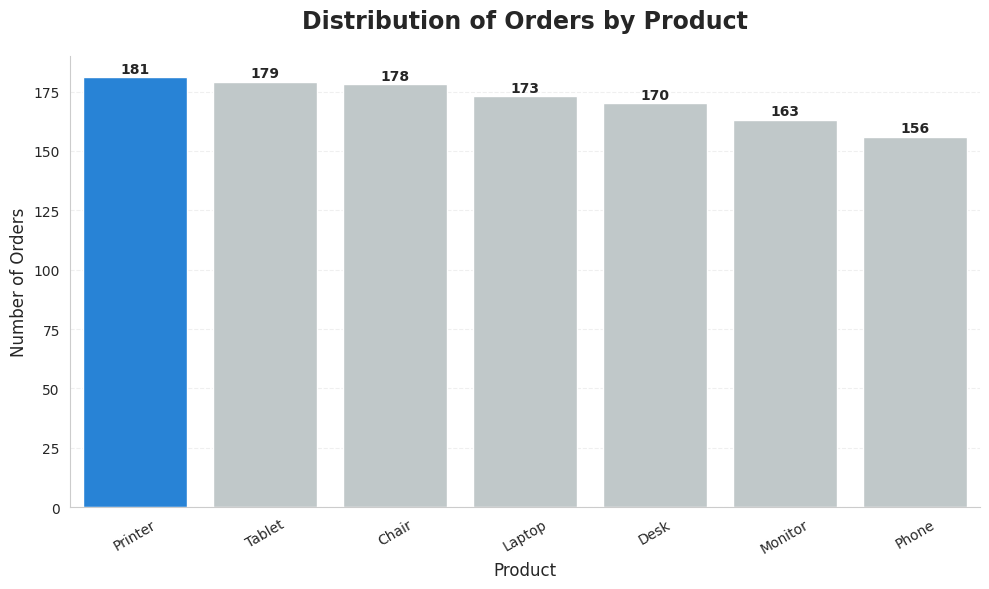

In [87]:
#Product Distribution
product_counts = df["Product"].value_counts()

colors = ["#0B84F3"] + ["#BFC9CA"] * (len(product_counts)-1)

plt.figure(figsize=(10,6))

ax = sns.barplot(
    x=product_counts.index,
    y=product_counts.values,
    hue=product_counts.index,
    palette=colors,
    legend=False
)

for i, value in enumerate(product_counts.values):
    ax.text(
        i,
        value+2,
        str(value),
        ha="center",
        fontsize=10,
        fontweight="bold"
    )

plt.title(
    "Distribution of Orders by Product",
    fontsize=17,
    fontweight="bold",
    pad=20
)

plt.xlabel("Product", fontsize=12)
plt.ylabel("Number of Orders", fontsize=12)

plt.xticks(rotation=30)

plt.grid(axis="y", linestyle="--", alpha=0.3)

sns.despine()

plt.tight_layout()

plt.show()

## 💡 Key Business Insights for Product Distribution

### Observation

- Printer recorded the highest number of orders, indicating strong customer demand.
- Phone received the fewest orders among all product categories.
- Order volumes across products remain relatively balanced, with no single category dominating the dataset.

###  Why It Matters

- Understanding product demand helps businesses optimize inventory levels and identify products that require additional marketing attention.

###  Business Recommendation

- Maintain sufficient stock for high-demand products while developing promotional strategies to improve sales of lower-performing categories.

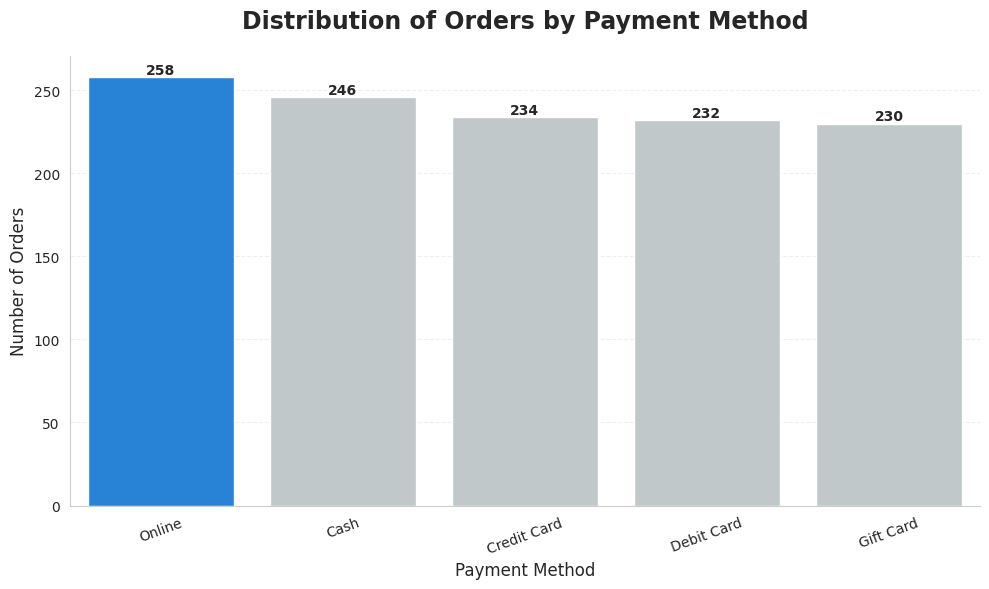

In [88]:
#Payment Method Distribution
payment_counts = df["PaymentMethod"].value_counts()

colors = ["#0B84F3"] + ["#BFC9CA"] * (len(payment_counts)-1)

plt.figure(figsize=(10,6))

ax = sns.barplot(
    x=payment_counts.index,
    y=payment_counts.values,
    hue=payment_counts.index,
    palette=colors,
    legend=False
)

for i, value in enumerate(payment_counts.values):
    ax.text(
        i,
        value + 2,
        str(value),
        ha="center",
        fontsize=10,
        fontweight="bold"
    )

plt.title(
    "Distribution of Orders by Payment Method",
    fontsize=17,
    fontweight="bold",
    pad=20
)

plt.xlabel("Payment Method", fontsize=12)
plt.ylabel("Number of Orders", fontsize=12)

plt.xticks(rotation=20)

plt.grid(axis="y", linestyle="--", alpha=0.3)

sns.despine()

plt.tight_layout()

plt.show()

## 💡 Key Business Insights for Payment Method Distribution

###  Observation

- Online was the most frequently used payment method, indicating a strong customer preference for digital transactions.
- Cash ranked second, while Credit Card, Debit Card, and Gift Card recorded similar order volumes.
- The distribution across payment methods is relatively balanced, suggesting customers are comfortable using multiple payment options.

###  Why It Matters

- Understanding payment preferences helps businesses optimize checkout experiences and focus on the payment methods most commonly used by customers.

###  Business Recommendation

- Continue improving the online payment experience to maintain customer satisfaction.
- Offer targeted promotions across less frequently used payment methods to encourage broader adoption.

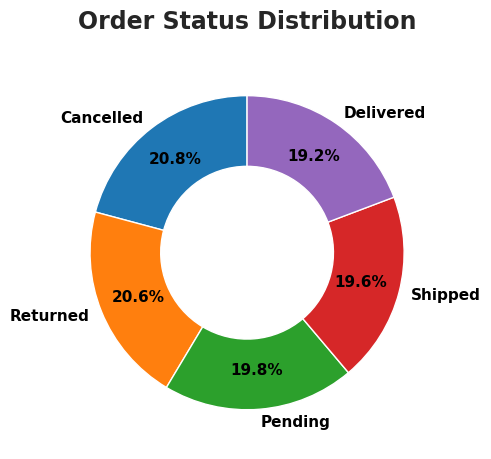

In [89]:
#Order Status
status_counts = df["OrderStatus"].value_counts()

plt.figure(figsize=(5,5))

plt.pie(
    status_counts.values,
    labels=status_counts.index,
    autopct="%1.1f%%",
    startangle=90,
    wedgeprops=dict(width=0.45),
    pctdistance=0.75,
    labeldistance=1.08,
    textprops={
        "fontsize":11,
        "fontweight":"bold",
        "color":"black"
    }
)

plt.title(
    "Order Status Distribution",
    fontsize=17,
    fontweight="bold",
    pad=20
)

plt.tight_layout()
plt.show()

## 💡 Key Business Insights for Order Status

###  Observation

- Cancelled orders recorded the highest count, followed closely by Returned orders.
- Delivered and Shipped orders accounted for a similar number of transactions.
- The distribution across order statuses is relatively balanced, with no single category overwhelmingly dominant.

###  Why It Matters

- Tracking order status helps businesses evaluate operational efficiency, customer satisfaction, and fulfillment performance.

###  Business Recommendation

- Investigate the causes of cancelled and returned orders to reduce revenue loss.
- Improve fulfillment processes to increase the proportion of successfully delivered orders.

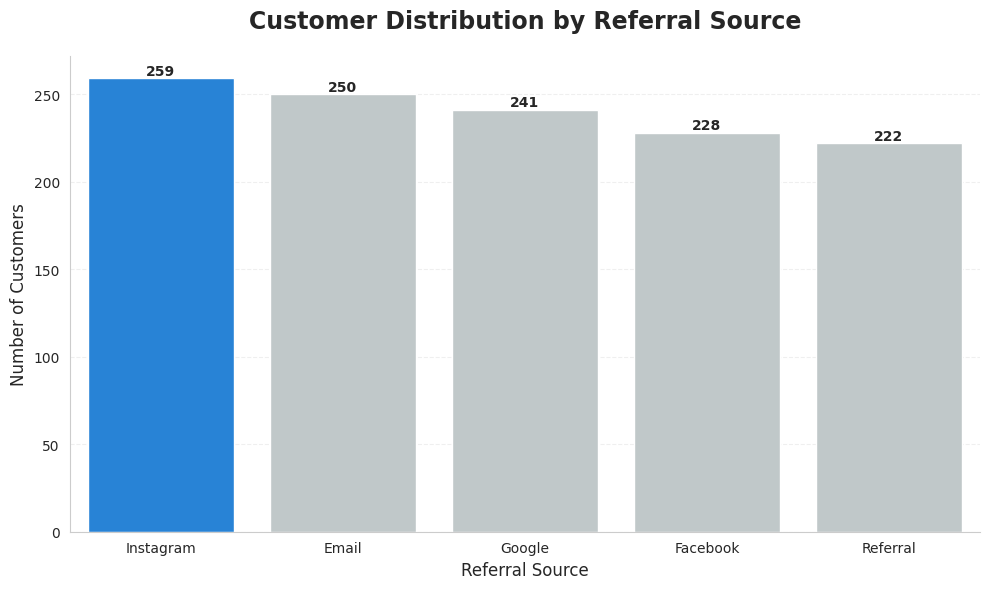

In [90]:
#Referral Source
referral_counts = df["ReferralSource"].value_counts()

colors = ["#0B84F3"] + ["#BFC9CA"] * (len(referral_counts)-1)

plt.figure(figsize=(10,6))

ax = sns.barplot(
    x=referral_counts.index,
    y=referral_counts.values,
    hue=referral_counts.index,
    palette=colors,
    legend=False
)

for i, value in enumerate(referral_counts.values):
    ax.text(
        i,
        value + 2,
        str(value),
        ha="center",
        fontsize=10,
        fontweight="bold"
    )

plt.title(
    "Customer Distribution by Referral Source",
    fontsize=17,
    fontweight="bold",
    pad=20
)

plt.xlabel("Referral Source", fontsize=12)
plt.ylabel("Number of Customers", fontsize=12)

plt.grid(axis="y", linestyle="--", alpha=0.3)

sns.despine()

plt.tight_layout()

plt.show()

## 💡 Key Business Insights for Referral Source

###  Observation

- Instagram attracted the highest number of customers among all referral sources.
- Email and Google also contributed a significant share of customer acquisitions.
- Referral generated the fewest customers, indicating lower participation in referral-based acquisitions.

###  Why It Matters

- Identifying the most effective customer acquisition channels helps businesses allocate marketing resources more efficiently and maximize return on investment.

###  Business Recommendation

- Continue investing in high-performing channels such as Instagram and Email.
- Optimize Google and Facebook campaigns to improve customer acquisition.
- Strengthen referral programs with incentives to encourage more customer referrals.

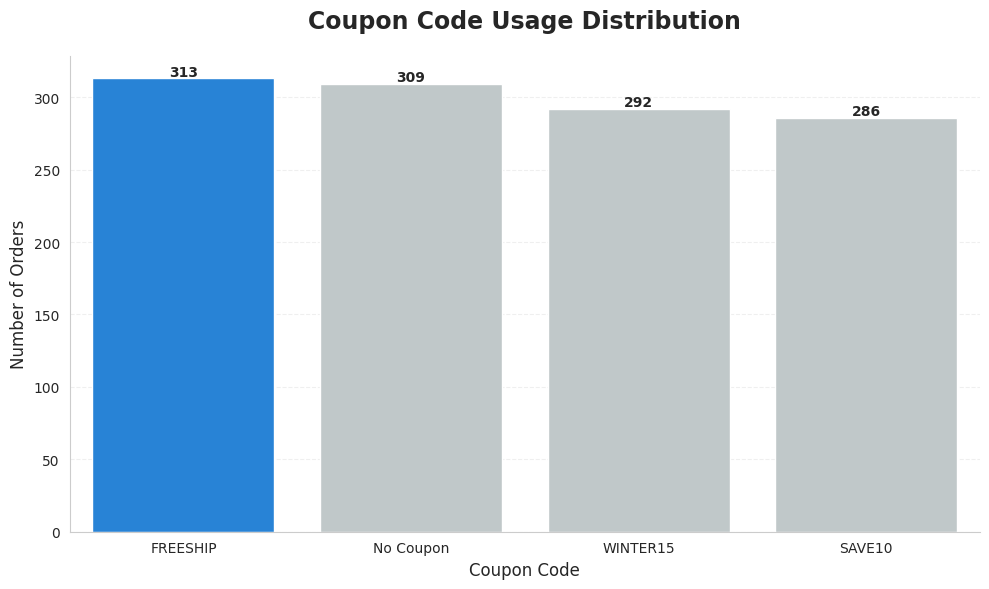

In [91]:
#Coupon Usage
coupon_counts = df["CouponCode"].value_counts()

colors = ["#0B84F3"] + ["#BFC9CA"] * (len(coupon_counts)-1)

plt.figure(figsize=(10,6))

ax = sns.barplot(
    x=coupon_counts.index,
    y=coupon_counts.values,
    hue=coupon_counts.index,
    palette=colors,
    legend=False
)

# Display values above bars
for i, value in enumerate(coupon_counts.values):
    ax.text(
        i,
        value + 2,
        str(value),
        ha="center",
        fontsize=10,
        fontweight="bold"
    )

plt.title(
    "Coupon Code Usage Distribution",
    fontsize=17,
    fontweight="bold",
    pad=20
)

plt.xlabel("Coupon Code", fontsize=12)
plt.ylabel("Number of Orders", fontsize=12)

plt.grid(axis="y", linestyle="--", alpha=0.3)

sns.despine()

plt.tight_layout()

plt.show()

## 💡 Key Business Insights for Coupon Usage

###  Observation

- **FREESHIP** was the most frequently used coupon code, making it the most popular promotional offer.
- **No Coupon** was the second most common category, indicating that many customers completed purchases without discounts.
- **WINTER15** and **SAVE10** were used less frequently, suggesting comparatively lower customer adoption.

###  Why It Matters

- Coupon usage provides valuable insights into customer purchasing behaviour and the effectiveness of promotional campaigns. Understanding which offers perform best helps businesses design more impactful marketing strategies.

###  Business Recommendation

- Continue offering high-performing promotions such as **FREESHIP** to attract and retain customers.
- Evaluate the performance of **WINTER15** and **SAVE10** to determine whether they require better promotion or revised discount structures.
- Analyze customers who purchase without coupons to understand opportunities for increasing average order value without relying on discounts.

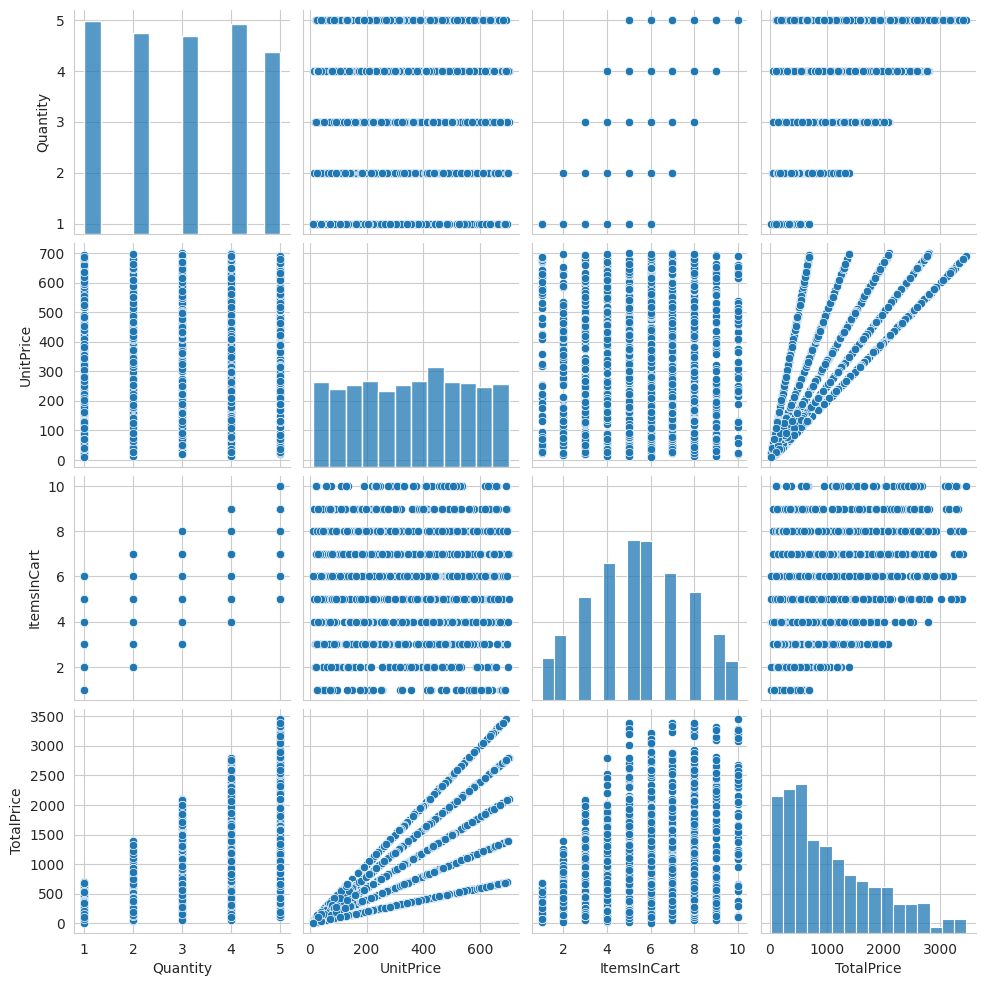

In [92]:
sns.pairplot(df[["Quantity","UnitPrice","ItemsInCart","TotalPrice"]])

## 💡 Key Insights for Pairplots

### Observation

- The pairplot compares every numerical variable with one another to identify relationships and patterns.
- Total Price shows a strong positive relationship with both Quantity and Unit Price.
- Items in Cart has a moderate positive relationship with Total Price.
- No unusual clusters or unexpected relationships are observed among the numerical features.

### Why It Matters

- Understanding these relationships helps identify the primary drivers of revenue. Quantity purchased and Unit Price have the greatest influence on Total Price.

### Business Recommendation

- Focus on strategies that encourage customers to purchase higher quantities or higher-value products, as both directly contribute to increasing overall revenue.

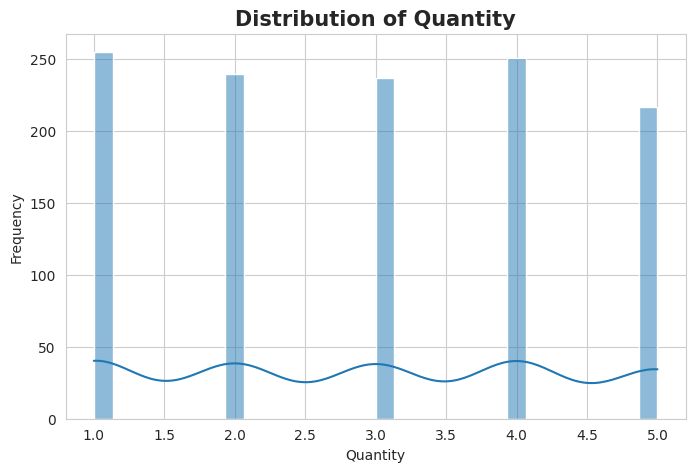

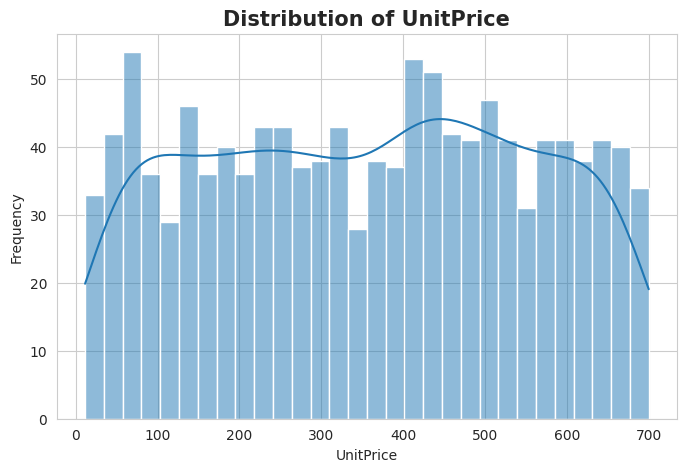

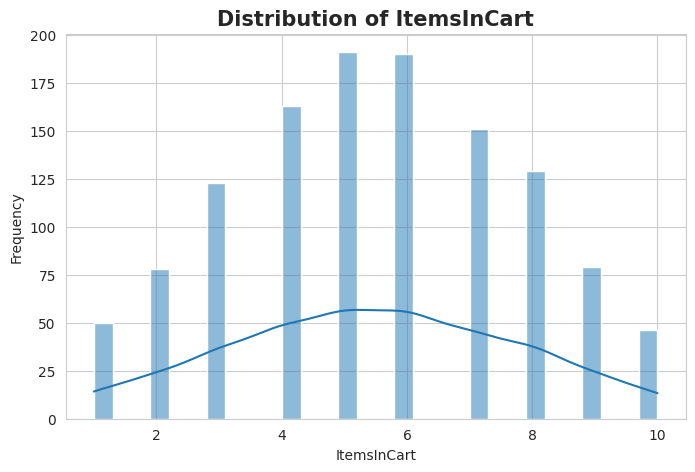

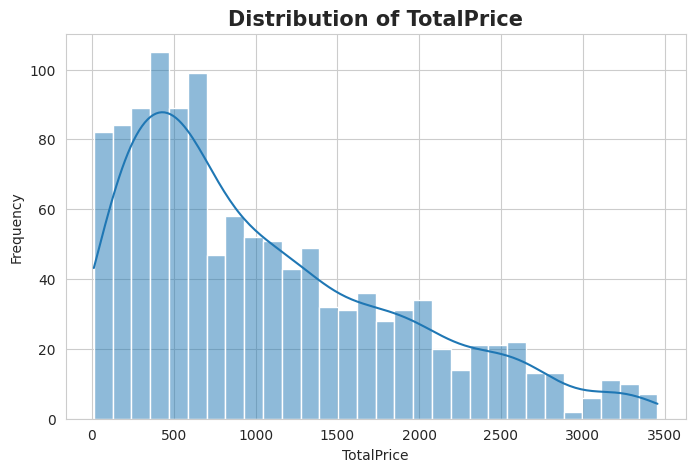

In [93]:
# Histograms of numerical columns

numerical_cols = ["Quantity", "UnitPrice", "ItemsInCart", "TotalPrice"]

for col in numerical_cols:
    plt.figure(figsize=(8,5))
    sns.histplot(df[col], bins=30, kde=True)

    plt.title(
    f"Distribution of {col}",
    fontsize=15,
    fontweight="bold"
)
    plt.xlabel(col)
    plt.ylabel("Frequency")

    plt.show()

## 💡 Key Business Insights for Histograms of numerical columns

###  Observation

- Quantity and Items in Cart show fairly balanced distributions, indicating consistent customer purchasing behaviour.
- Unit Price is distributed across a wide range of products.
- Total Price is right-skewed, with most orders being low to medium value while a small number of high-value purchases are present.

###  Why It Matters

- Understanding these distributions helps identify typical customer purchasing patterns and highlights the presence of occasional high-value transactions.

###  Business Recommendation

- Focus marketing efforts on increasing average order value through product bundles, cross-selling, and promotions that encourage customers to purchase more items per order.

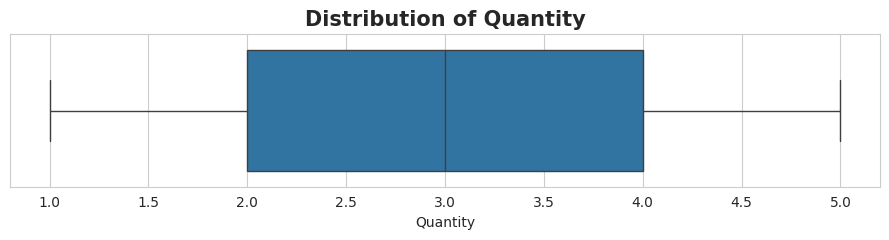

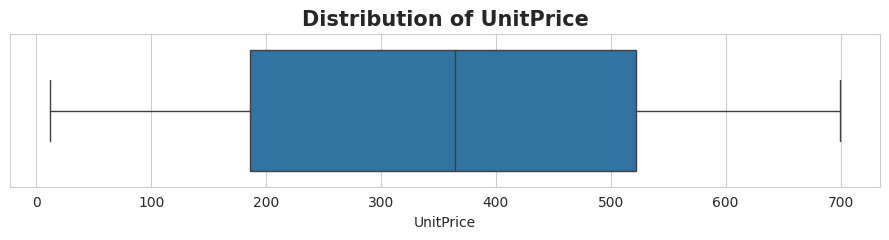

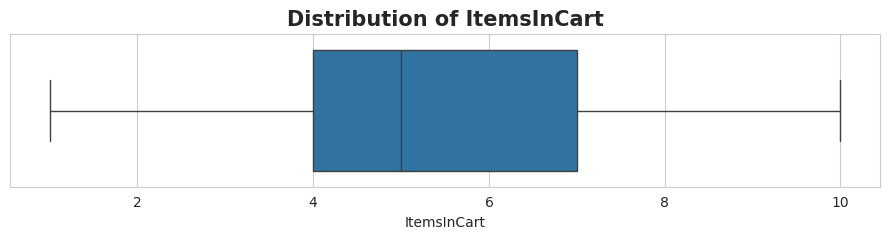

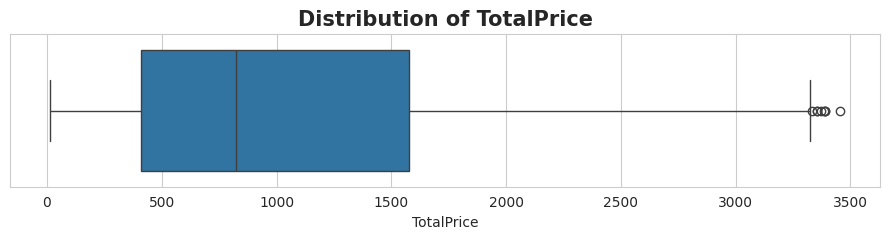

In [94]:
# Boxplots
for col in numerical_cols:
    plt.figure(figsize=(9,2.5))
    sns.boxplot(x=df[col])
    
    plt.title(
        f"Distribution of {col}",
        fontsize=15,
        fontweight="bold"
    )

    plt.tight_layout()

    plt.show()

## 💡 Key Business Insights for Boxplots

###  Observation

- Quantity, Unit Price, and Items in Cart show relatively consistent distributions with no major outliers.
- Total Price contains a few high-value outliers, indicating that some customers place significantly larger or higher-value orders than average.

###  Why It Matters

- Identifying outliers helps businesses understand unusual purchasing behaviour and distinguish premium or bulk orders from typical transactions.

###  Business Recommendation

- Monitor high-value transactions to identify valuable customer segments and tailor premium offers or loyalty programs accordingly.

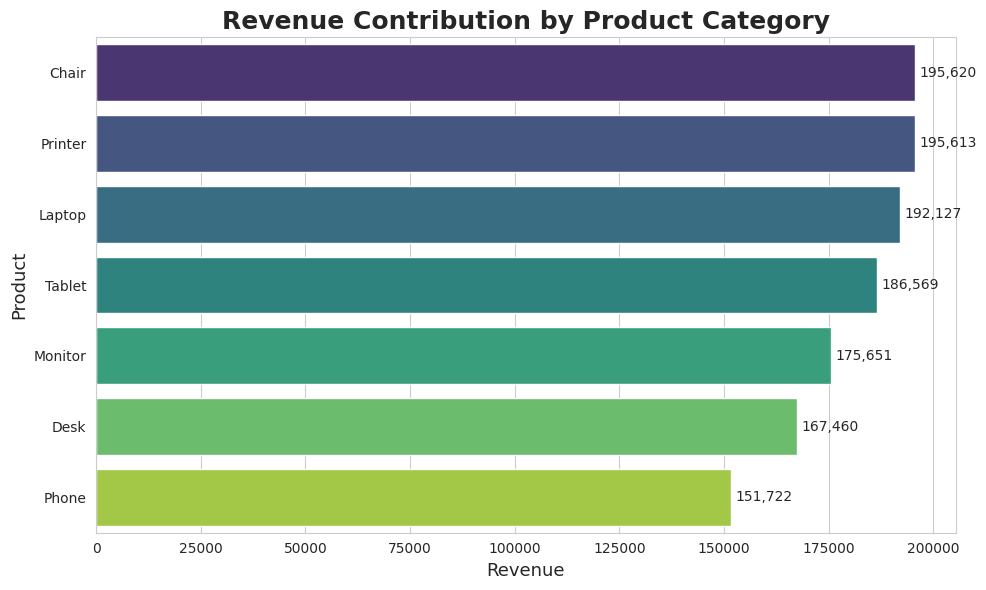

In [95]:
#Revenue By Product
product_sales = df.groupby("Product")["TotalPrice"].sum().sort_values(ascending=False)

plt.figure(figsize=(10,6))

sns.barplot(
    x=product_sales.values,
    y=product_sales.index,
    hue=product_sales.index,          
    palette="viridis"
)

for i, value in enumerate(product_sales.values):
    plt.text(value + 1000, i, f"{value:,.0f}", va='center')

plt.title(
    "Revenue Contribution by Product Category",
    fontsize=18,
    fontweight='bold'
)

plt.xlabel("Revenue", fontsize=13)
plt.ylabel("Product", fontsize=13)

plt.tight_layout()
plt.show()

##  💡Key Business Insight for Revenue By Product

- Chair generated the highest total revenue (195,620), making it the top-performing product.
- Printer and Laptop closely followed, indicating that these three products contribute a significant share of overall sales.
- Phone generated the lowest revenue among all product categories.
- Maintaining adequate inventory and marketing efforts for the top-performing products could help maximize future revenue.

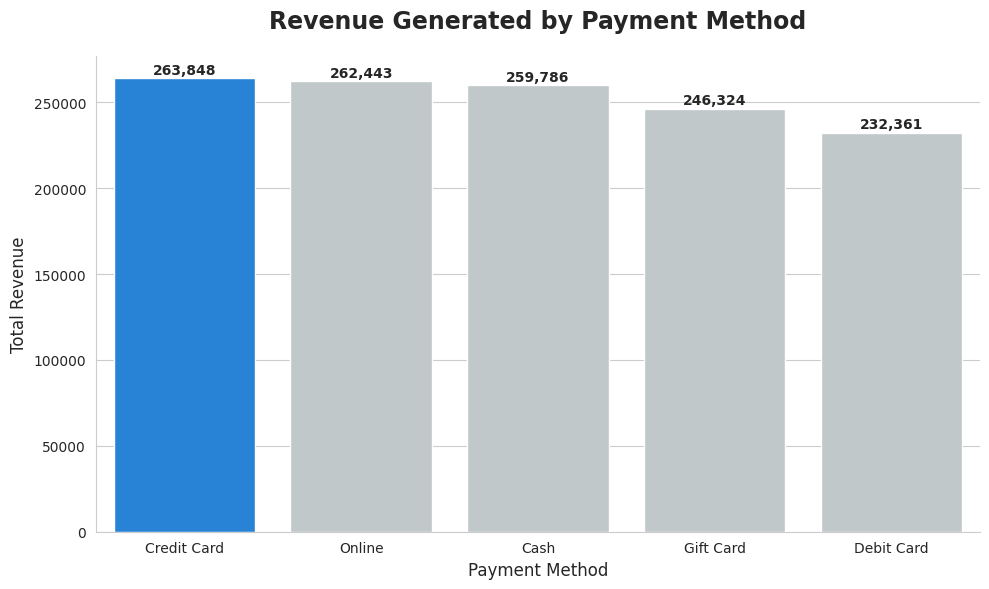

In [96]:
#Revenue by Payment Method
payment_sales = (
    df.groupby("PaymentMethod")["TotalPrice"]
      .sum()
      .sort_values(ascending=False)
)

colors = ["#0B84F3"] + ["#BFC9CA"] * (len(payment_sales) - 1)

plt.figure(figsize=(10,6))

ax = sns.barplot(
    x=payment_sales.index,
    y=payment_sales.values,
    hue=payment_sales.index,          
    palette=colors,
    legend=False
)

for i, value in enumerate(payment_sales.values):
    ax.text(
        i,
        value + 2500,
        f"{value:,.0f}",
        ha="center",
        fontsize=10,
        fontweight="bold"
    )
    
plt.title(
    "Revenue Generated by Payment Method",
    fontsize=17,
    fontweight="bold",
    pad=20
)

plt.xlabel("Payment Method", fontsize=12)
plt.ylabel("Total Revenue", fontsize=12)

sns.despine()

plt.tight_layout()
plt.show()

## 💡Key Business Insights for Revenue by Payment Method

### Observation
 - Credit Card payments generated the highest revenue (≈264,000), making them the most valuable payment method.
 - Online and Cash payments closely followed, indicating customers are comfortable using multiple digital payment options.
 - Debit Card generated the lowest revenue among all payment methods.

### Why it Matters
- The majority of revenue comes from customers using digital payment methods, especially Credit Cards. This suggests these customers tend to make higher-value purchases.

### Business Recommendation
 - Offer exclusive cashback or loyalty rewards for Credit Card users to improve customer retention.
 - Run promotional campaigns for Debit Card users to encourage higher spending and increase adoption.

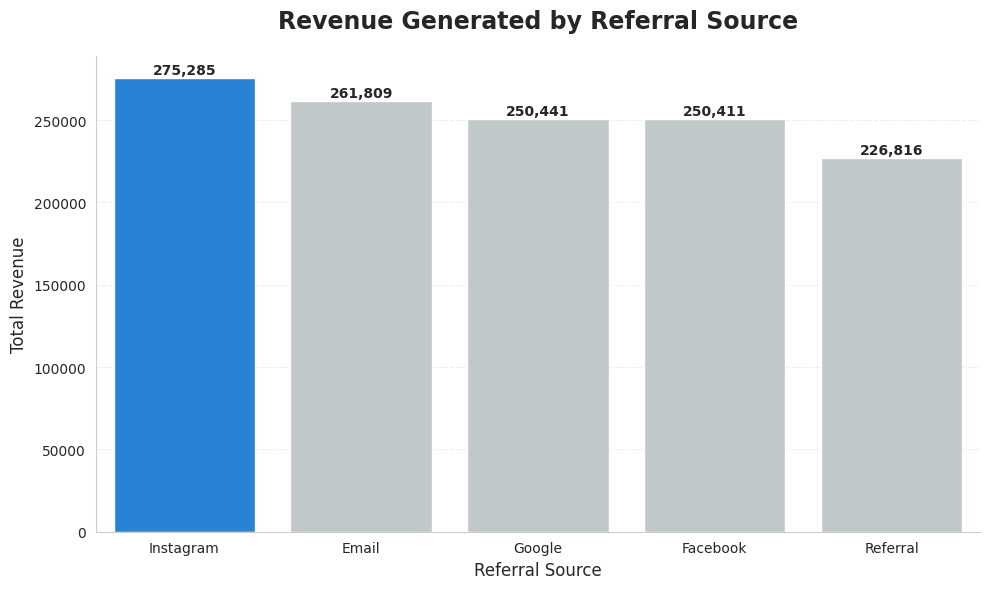

In [97]:
# Revenue by Referral Source
referral_sales = (
    df.groupby("ReferralSource")["TotalPrice"]
      .sum()
      .sort_values(ascending=False)
)

colors = ["#0B84F3"] + ["#BFC9CA"] * (len(referral_sales) - 1)

plt.figure(figsize=(10,6))

ax = sns.barplot(
    x=referral_sales.index,
    y=referral_sales.values,
    hue=referral_sales.index,
    palette=colors,
    legend=False
)

for i, value in enumerate(referral_sales.values):
    ax.text(
        i,
        value + 2500,
        f"{value:,.0f}",
        ha="center",
        fontsize=10,
        fontweight="bold"
    )

plt.title(
    "Revenue Generated by Referral Source",
    fontsize=17,
    fontweight="bold",
    pad=20
)

plt.xlabel("Referral Source", fontsize=12)
plt.ylabel("Total Revenue", fontsize=12)

plt.grid(axis='y', linestyle='--', alpha=0.3)

sns.despine()

plt.tight_layout()
plt.show()

## 💡 Key Business Insights for Revenue by Referral Source

###  Observation

- Instagram generated the highest total revenue, making it the strongest customer acquisition channel.
- Email ranked second, followed closely by Google and Facebook, indicating that multiple digital marketing channels contribute significantly to sales.
- Referral generated the lowest revenue among all acquisition sources.

###  Why it Matters

Revenue is primarily driven by digital marketing channels, with Instagram delivering the highest return. Understanding which acquisition channels perform best helps businesses allocate their marketing budget more effectively.

###  Business Recommendation

- Continue investing in Instagram campaigns to maximize customer acquisition and revenue.
- Optimize Email, Google, and Facebook campaigns to further improve conversion rates.
- Reassess the Referral program to identify opportunities for increasing customer participation.

In [98]:
# Time Series Analysis

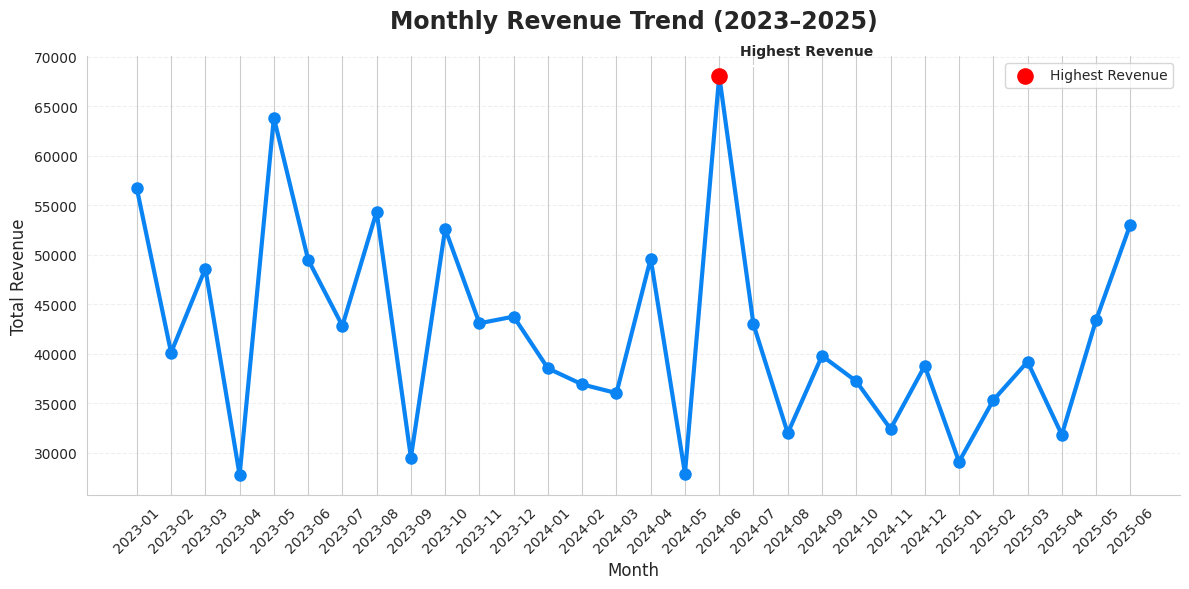

In [99]:
#Monthly Revenue Trend (2023–2025)

monthly_sales = (
    df.groupby(df["Date"].dt.to_period("M"))["TotalPrice"]
      .sum()
)

monthly_sales.index = monthly_sales.index.astype(str)

plt.figure(figsize=(12,6))

plt.plot(
    monthly_sales.index,
    monthly_sales.values,
    marker="o",
    markersize=8,
    linewidth=3,
    color="#0B84F3"
)

max_idx = monthly_sales.values.argmax()

plt.scatter(
    monthly_sales.index[max_idx],
    monthly_sales.values[max_idx],
    color="red",
    s=120,
    zorder=5,
    label="Highest Revenue"
)

plt.annotate(
    "Highest Revenue",
    (
        monthly_sales.index[max_idx],
        monthly_sales.values[max_idx]
    ),
    xytext=(15,15),
    textcoords="offset points",
    arrowprops=dict(
        arrowstyle="->",
        lw=1.5
    ),
    fontsize=10,
    fontweight="bold"
)

plt.title(
    "Monthly Revenue Trend (2023–2025)",
    fontsize=17,
    fontweight="bold",
    pad=20
)

plt.xlabel("Month", fontsize=12)
plt.ylabel("Total Revenue", fontsize=12)

plt.xticks(rotation=45)

plt.grid(
    axis="y",
    linestyle="--",
    alpha=0.3
)

sns.despine()

plt.tight_layout()
plt.legend()

plt.show()

## 💡Key Business Insights for Monthly Revenue Trend (2023–2025)

### Observation

- Monthly revenue fluctuated considerably between 2023 and 2025, indicating changing customer demand over time.
- The highlighted month recorded the highest revenue during the observed period, while several months experienced comparatively lower sales.
- Revenue patterns suggest that customer purchasing behaviour varies throughout the year.

### Why It Matters

- Monitoring monthly revenue trends helps businesses identify high-performing periods, forecast future demand, and optimize inventory and marketing strategies.

### Business Recommendation

- Analyze the factors that contributed to the highest-performing month and replicate successful marketing campaigns where possible.
- Increase inventory and promotional efforts during historically strong months.
- Investigate lower-performing months to identify opportunities for improving customer engagement and boosting sales.

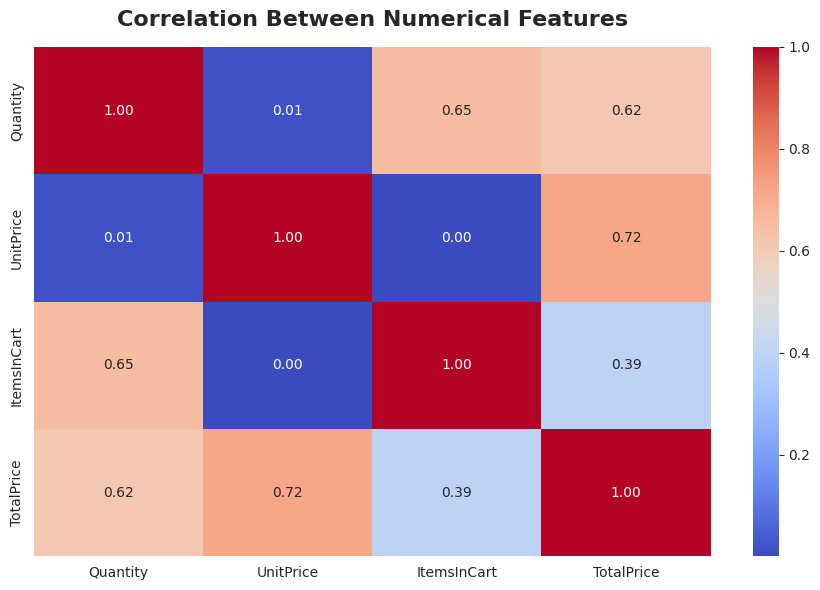

In [100]:
# Correlation Analysis
numeric_df = df.select_dtypes(include="number")

plt.figure(figsize=(9,6))

sns.heatmap(
    numeric_df.corr(),
    annot=True,
    annot_kws={"size":10},
    cmap="coolwarm",
    fmt=".2f"
)

plt.title(
    "Correlation Between Numerical Features",
    fontsize=16,
    fontweight="bold",
    pad=15
)

plt.tight_layout()

plt.show()

## 💡Key Business Insights for Correlation Analysis

### Observation

- Total Price shows a strong positive correlation with both Quantity (0.62) and Unit Price (0.72).
- Quantity and Items in Cart also demonstrate a moderate positive relationship.
- Unit Price has almost no relationship with Items in Cart.

### Why It Matters

- Higher quantities and higher-priced products directly contribute to increased order value, making them the primary drivers of revenue.

### Business Recommendation

- Focus on strategies that encourage customers to purchase larger quantities or higher-value products to maximize overall revenue.

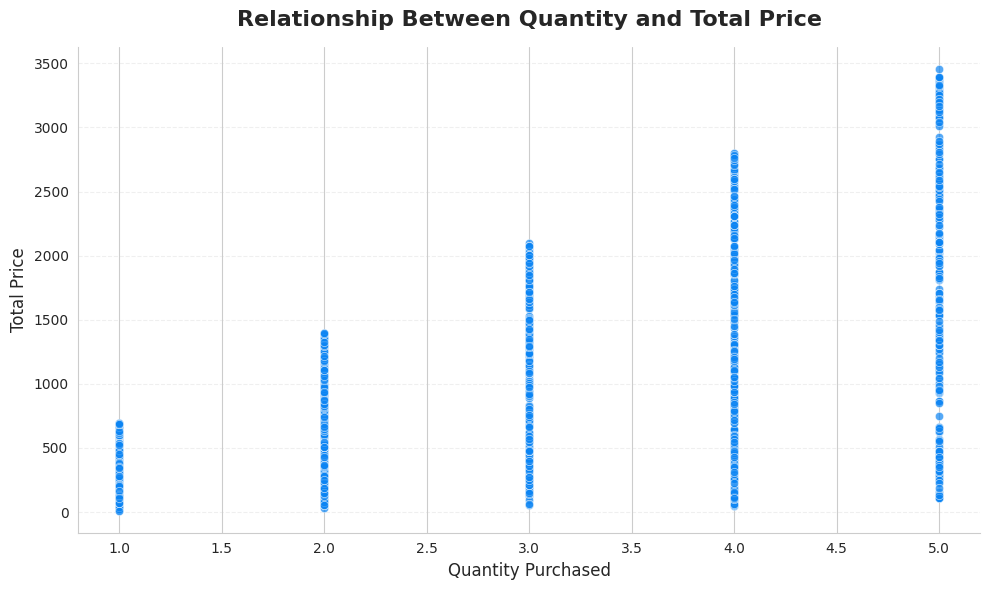

In [101]:
#Relationship between Quantity and Total Price
plt.figure(figsize=(10,6))

sns.scatterplot(
    data=df,
    x="Quantity",
    y="TotalPrice",
    color="#0B84F3",
    alpha=0.7
)

plt.title(
    "Relationship Between Quantity and Total Price",
    fontsize=16,
    fontweight="bold",
    pad=15
)

plt.xlabel("Quantity Purchased", fontsize=12)
plt.ylabel("Total Price", fontsize=12)

plt.grid(axis="y", linestyle="--", alpha=0.3)

sns.despine()

plt.tight_layout()

plt.show()

## 💡 Key Business Insights for Relationship between Quantity and Total Price

###  Observation

- A clear positive relationship exists between Quantity Purchased and Total Price.
- Orders containing larger quantities generally result in higher transaction values.
- A few high-value transactions appear as outliers, indicating occasional premium or bulk purchases.

###  Why It Matters

- Increasing the number of items purchased per order directly increases revenue and improves average order value.

###  Business Recommendation

- Encourage customers to purchase additional items through product bundles, volume discounts, and cross-selling strategies to maximize revenue.

# 📋 Final Business Recommendations

Based on the analysis of this e-commerce dataset, here are some recommendations that could help improve the business:

###  Inventory Management
- Keep enough stock of products that receive the most orders to avoid running out of inventory.
- Monitor monthly sales trends to prepare inventory during high-demand periods.

###  Marketing
- Continue promoting products through Instagram since it brought in the highest number of customers and generated the highest revenue.
- Improve marketing on channels like Facebook and Referral to attract more customers.

###  Payment Methods
- Since Credit Card users generated the highest revenue, offering cashback or loyalty rewards could encourage more customers to use this payment method.
- Continue improving the online payment experience to make purchases easier for customers.

###  Coupon Strategy
- FREESHIP was the most popular coupon, so similar offers could be used in future promotions.
- Review the performance of WINTER15 and SAVE10 to understand why they were used less often.

###  Future Improvements
- Study why some orders were cancelled or returned so that these numbers can be reduced.
- In the future, this analysis could be extended using Power BI dashboards or machine learning models to predict customer behaviour and future sales.